# 02 - Baseline CNN Classification

This notebook trains a simple CNN from scratch at 128x128 resolution and evaluates it on the official test split.

## Google Colab Git Setup

Run the next cell only when using Google Colab.


In [2]:
# Colab-only Git setup. Skip this cell when running locally.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/andri-10/computer_vision.git"

REPO_DIR = Path("/content/computer_vision")
PROJECT_DIR = REPO_DIR / "PetVision-DeepLearning"

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    if REPO_DIR.exists():
        subprocess.check_call(["git", "-C", str(REPO_DIR), "pull", "origin", "main"])
    else:
        subprocess.check_call(["git", "clone", REPO_URL, str(REPO_DIR)])

    os.chdir(PROJECT_DIR)

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"
    ])

    print("Colab repo root:", REPO_DIR)
    print("Colab project root:", os.getcwd())
else:
    print("Not running in Google Colab. Continue with the local setup cells below.")

Colab repo root: /content/computer_vision
Colab project root: /content/computer_vision/PetVision-DeepLearning


In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

for path in [
    "models",
    "results/classification",
    "results/segmentation",
    "results/gradcam",
    "results/figures",
]:
    (PROJECT_ROOT / path).mkdir(parents=True, exist_ok=True)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from src.data_loader import get_splits, configure_for_performance, save_label_mapping
from src.preprocessing import preprocess_baseline_classification
from src.models_classification import build_baseline_cnn, compile_classifier
from src.training import standard_callbacks
from src.evaluation import collect_predictions, save_classification_outputs, top_k_accuracy
from src.visualization import plot_training_history, plot_confusion_matrix

In [5]:
BATCH_SIZE = 32
EPOCHS = 3

train_raw, val_raw, test_raw, info, label_names = get_splits()
save_label_mapping(label_names, PROJECT_ROOT / "results/figures/label_mapping.json")

train_ds = configure_for_performance(train_raw.map(preprocess_baseline_classification, num_parallel_calls=tf.data.AUTOTUNE), BATCH_SIZE, shuffle=True)
val_ds = configure_for_performance(val_raw.map(preprocess_baseline_classification, num_parallel_calls=tf.data.AUTOTUNE), BATCH_SIZE)
test_ds = configure_for_performance(test_raw.map(preprocess_baseline_classification, num_parallel_calls=tf.data.AUTOTUNE), BATCH_SIZE)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.MM9FDK_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.MM9FDK_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [6]:
model = build_baseline_cnn(input_shape=(128, 128, 3), num_classes=len(label_names))
compile_classifier(model, learning_rate=1e-3)
model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_augmentation     │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,437 (1.26 MB)

 Trainable params: 329,989 (1.26 MB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=standard_callbacks(PROJECT_ROOT / "models/baseline_classifier.keras", patience=4),
)
plot_training_history(history, PROJECT_ROOT / "results/classification/baseline_training_curves.png", "Baseline CNN")

Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 38s 199ms/step - accuracy: 0.0448 - loss: 3.6368 - top_3_accuracy: 0.1135 - val_accuracy: 0.0367 - val_loss: 3.6874 - val_top_3_accuracy: 0.0883 - learning_rate: 0.0010
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 182ms/step - accuracy: 0.0547 - loss: 3.5330 - top_3_accuracy: 0.1471 - val_accuracy: 0.0245 - val_loss: 3.9422 - val_top_3_accuracy: 0.0815 - learning_rate: 0.0010
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 177ms/step - accuracy: 0.0673 - loss: 3.4907 - top_3_accuracy: 0.1709 - val_accuracy: 0.0272 - val_loss: 4.2908 - val_top_3_accuracy: 0.0965 - learning_rate: 0.0010


In [8]:
test_metrics = model.evaluate(test_ds, verbose=1)
print(dict(zip(model.metrics_names, test_metrics)))

y_true, y_pred, y_prob = collect_predictions(model, test_ds)
print("Top-3 accuracy:", top_k_accuracy(y_true, y_prob, k=3))
save_classification_outputs(y_true, y_pred, label_names, PROJECT_ROOT / "results/classification/baseline")
plot_confusion_matrix(y_true, y_pred, label_names, PROJECT_ROOT / "results/classification/baseline_confusion_matrix.png")

115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.0362 - loss: 3.6828 - top_3_accuracy: 0.0899
{'loss': 3.682777166366577, 'compile_metrics': 0.036249659955501556}
Top-3 accuracy: 0.08994276369582993


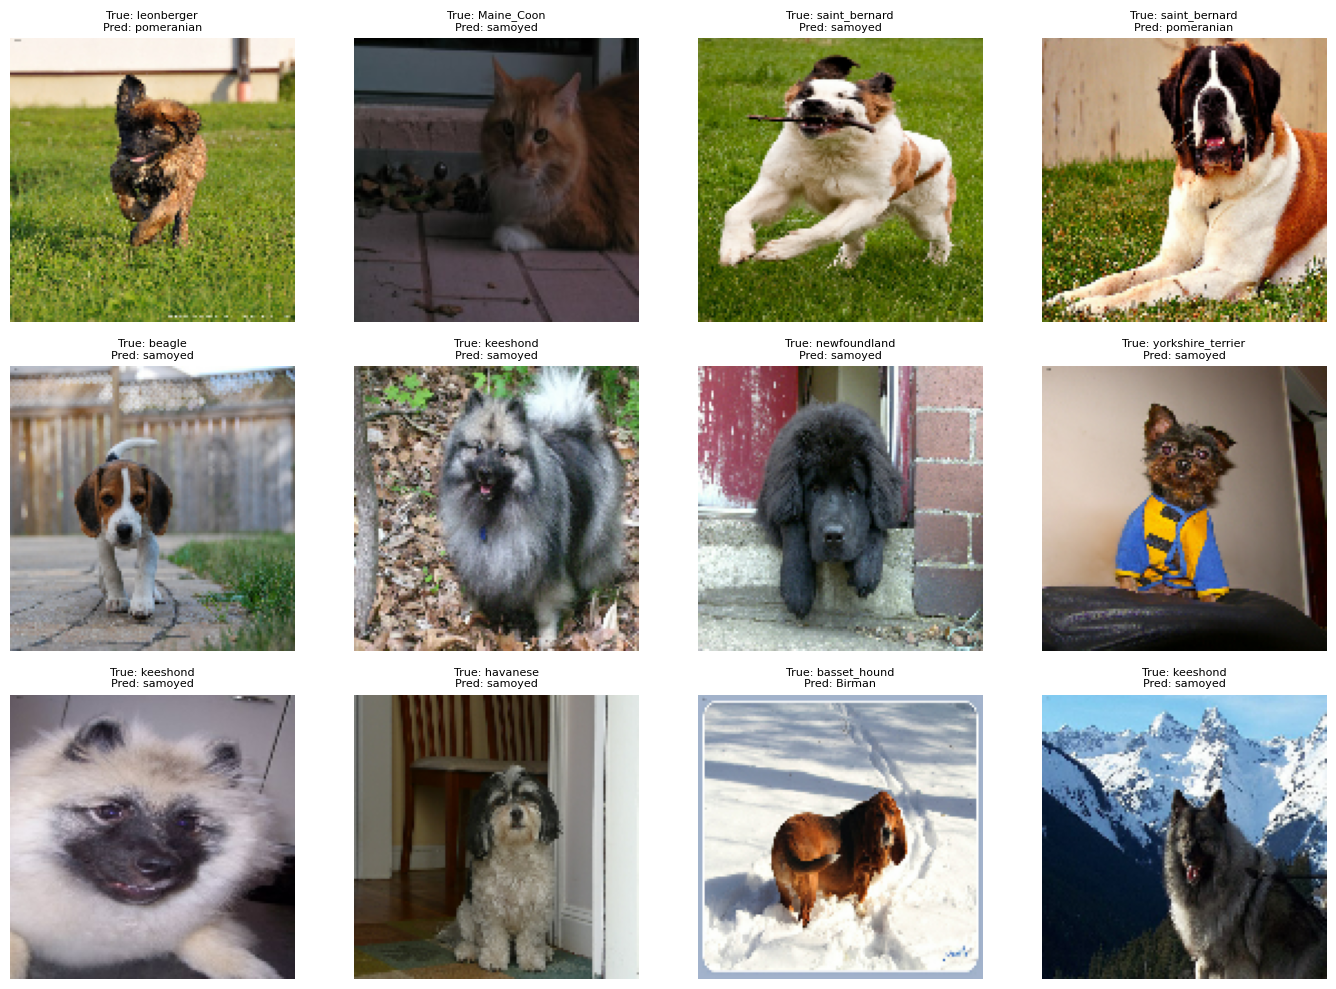

In [9]:
# Show wrong predictions.
wrong_indices = np.where(y_true != y_pred)[0][:12]
images, labels = [], []
for batch_images, batch_labels in test_ds.unbatch().take(500):
    images.append(batch_images.numpy())
    labels.append(int(batch_labels.numpy()))
images = np.array(images)
labels = np.array(labels)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for ax, idx in zip(axes.ravel(), wrong_indices):
    ax.imshow(images[idx])
    ax.set_title(f"True: {label_names[y_true[idx]]}\nPred: {label_names[y_pred[idx]]}", fontsize=8)
    ax.axis("off")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "results/classification/baseline_wrong_predictions.png", dpi=160)
plt.show()